# Decision Tree Regression

The objective of this notebook is to implement Decision Tree Regression using Scikit-learn.

Decision Tree Regression is a non-linear supervised machine learning algorithm that predicts continuous values by recursively splitting the dataset into smaller subsets based on feature values.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
project_root = Path.cwd().parent              # Data transformed from data transformation

train_path = project_root / "artifacts" / "data_transformation" / "train.npy"
test_path = project_root / "artifacts" / "data_transformation" / "test.npy"

train_arr = np.load(train_path)
test_arr = np.load(test_path)

In [5]:
X_train = train_arr[:, :-1]
y_train = train_arr[:, -1]   # The transformed arrays contain both the input features and the target variable.

X_test = test_arr[:, :-1]
y_test = test_arr[:, -1]

In [6]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(436, 14)
(436,)
(109, 14)
(109,)



The Decision Tree Regression model is created using Scikit-learn.

Unlike Linear Regression, Decision Trees learn decision rules by recursively splitting the data rather than fitting a mathematical equation.

In [7]:
model = DecisionTreeRegressor(max_depth=3,random_state=42)

In [8]:
print(model)

DecisionTreeRegressor(max_depth=3, random_state=42)


In [9]:
model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [10]:
y_pred = model.predict(X_test)

print("Predicted House Prices:")           # predict house values
print(y_pred[:5])

Predicted House Prices:
[6061125.         7032826.18181818 4069085.61643836 4069085.61643836
 4069085.61643836]


In [11]:
comparison = np.column_stack((y_test, y_pred))

print("Actual Price\tPredicted Price")          # compare actual vs predicted 
print(comparison[:10])

Actual Price	Predicted Price
[[4060000.         6061125.        ]
 [6650000.         7032826.18181818]
 [3710000.         4069085.61643836]
 [6440000.         4069085.61643836]
 [2800000.         4069085.61643836]
 [4900000.         5245901.31578947]
 [5250000.         5245901.31578947]
 [4543000.         6061125.        ]
 [2450000.         3284130.20833333]
 [3353000.         4069085.61643836]]


In [12]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)           #evaluate model

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 1327852.66
Mean Squared Error (MSE): 3152798618642.12
Root Mean Squared Error (RMSE): 1775612.18
R² Score: 0.3762


In [13]:
feature_names = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus_furnished",
    "furnishingstatus_semi-furnished",
    "furnishingstatus_unfurnished",
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]

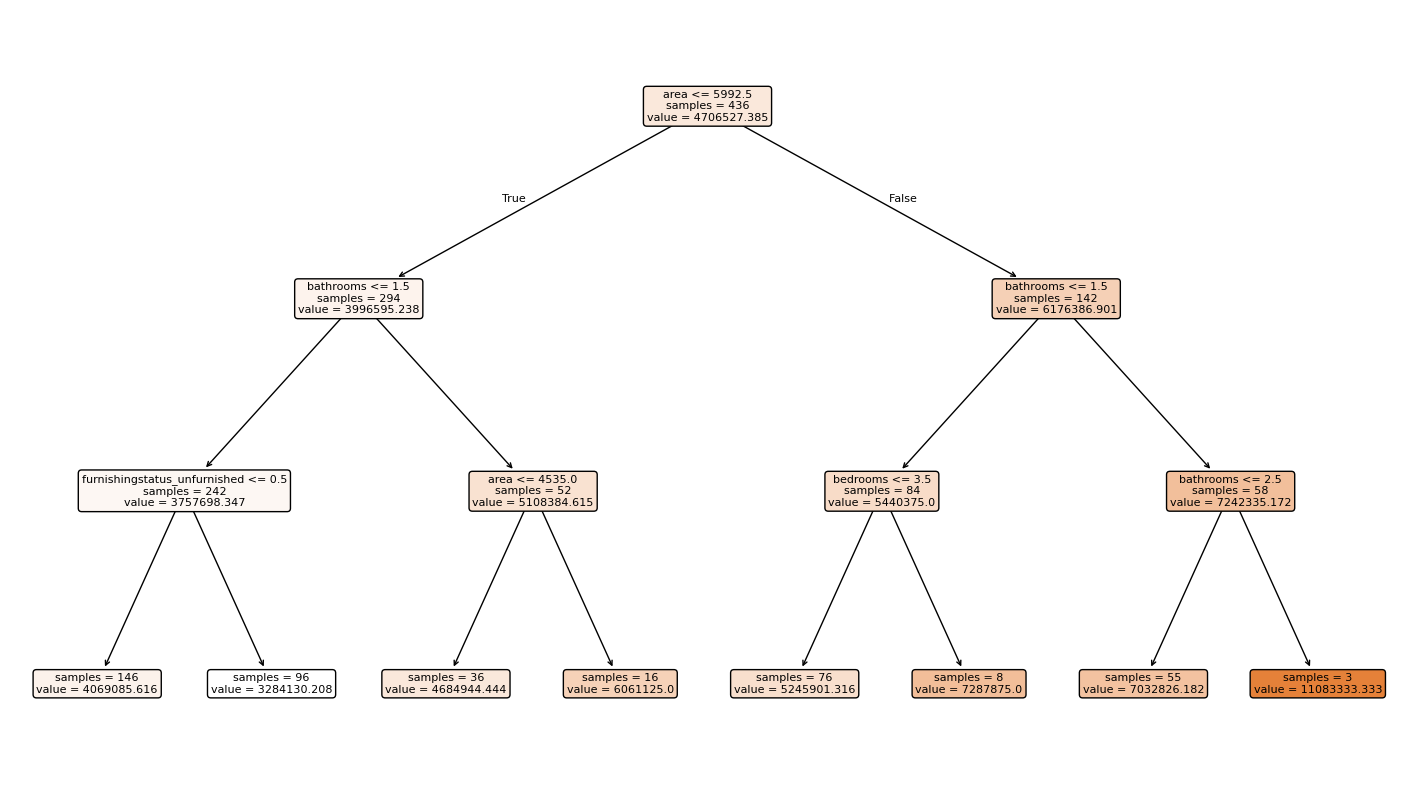

In [14]:
model_small = DecisionTreeRegressor(
    max_depth=3,                                 #data visualize
    random_state=42
)

model_small.fit(X_train, y_train)


plt.figure(figsize=(18,10))

plot_tree(
    model_small,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=8,
    impurity=False
)

plt.show()

# The trained Decision Tree can be visualized to understand how it makes predictions. 
#Each internal node represents a decision rule, while each leaf node represents the predicted target value.

In [15]:
importance = model.feature_importances_

print("Feature Importance:")                   # Feature Importance
print(importance)


# Decision Tree Regression computes feature importance based on how much each feature contributes to reducing prediction error.
# Features with higher importance have a greater influence on the model's predictions.

Feature Importance:
[0.         0.         0.         0.         0.         0.
 0.         0.         0.04587026 0.61177086 0.03879333 0.30356556
 0.         0.        ]
